# ABCMB Fluids

In this script we demonstrate how to efficiently implement a new physics particle species to the cosmological model, using the `Fluid` module in ABCMB.

# Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
sys.path.append('..')

from classy import Class
from ABCMB.main import Model
from ABCMB.species import Fluid, StandardFluid, BackgroundFluid
import ABCMB.constants as cnst
from ABCMB import species, spectrum

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import equinox as eqx

## A $\Lambda {\rm CDM}$ Run

We first perform a standard cosmology run to compare our subsequent results to.

In [14]:
LCDM = Model()
output_LCDM, aux_LCDM = LCDM.run_cosmology({})

You did not specify either N_nu_massless or Neff, and did not ask LINX to compute these quantities.
N_nu_massless will be set to 3-N_nu_massive=3.

              /\  
             /  \   
            / /\ \  
           / /__\ \    ___   ___  
          / ______ \  | _ \ / __\ _  _  
         / /      \ \ |  _// /   | \/ | __  
        / /        \ \| _ \\ \___||\/||| -)  
       /_/          \_|___/ \___/||  |||_-) is compiling...
\_____/      



In [21]:
l = aux_LCDM[0]
tt = output_LCDM[0] * l * (l+1) / 2 / jnp.pi
te = output_LCDM[1] * l * (l+1) / 2 / jnp.pi
ee = output_LCDM[2] * l * (l+1) / 2 / jnp.pi

k = aux_LCDM[1]
Pk = output_LCDM[3]

# The Fluid Module

The fluid modules are the building blocks of a cosmological model in ABCMB. Each fluid module contains labels, characteristics, as well as instructions on how to compute various functions that are unique to that fluid. 

## The Module

Each fluid should inherit from the base class `Fluid` in ABCMB. Here's a look of its structure copied over from species.py:

In [5]:
class Fluid(eqx.Module):
    """
    Base class for fluid species.

    Defines fluid properties.

    Fields:
    -------
    delta_idx : int
        Default = 0
        Position of the first perturbation equation in the Diffrax vector. For most fluids this is the density perturbation mode "delta".
    num_ell_modes : int 
        Default = 0
        Number of equations that need to be simultaneously evolved in the perturbations module. 
    name : str
        Default = ""
        Name of the fluid, used to find fluid and refer to it later in the computation using species_dict["name"].
    is_matter : bool
        Default = False
        Whether the fluid is non-relativistic today and contributes towards the total matter power spectrum. 

    Methods:
    --------
    Background Quantities:
        rho : Compute energy density (units: eV cm^{-3})
        P   : Compute pressure (units: eV cm^{-3})
        w   : Compute equation of state parameter (units: dimensionless)

    Perturbation Quantities:
        y_ini   : Adiabatic initial conditions, in synchronous gauge
        y_prime : Perturbation derivatives, in synchronous gauge
        rho_delta        : Perturbed density function δρ (units: eV cm^{-3})
        rho_plus_P_theta : Velocity perturbation  (units: eV cm^{-3})
        rho_plus_P_sigma : Compute standard shear perturbation (units: eV cm^{-3})
    """

    delta_idx     : int = eqx.field(default=0)
    num_ell_modes : int = eqx.field(default=0, static=True)
    name          : str = eqx.field(default="")
    is_matter     : bool = eqx.field(default=False) # Does the fluid contribute towards matter overdensity today.

    def __init__(self, delta_idx, specs):
        self.delta_idx = delta_idx

    def rho(self, lna, args):
        raise NotImplementedError("Fluid species must implement an energy density function.")

    def P(self, lna, args):
        raise NotImplementedError("Fluid species must implement a pressure function.")

    def w(self, lna, args):
        return self.P(lna, args)/self.rho(lna, args)

    def y_ini(self, k, tau_ini, om, args):
        raise NotImplementedError("Fluid species must implement the initial conditions of their perturbation modes.")

    def y_prime(self, k, lna, metric_h_prime, metric_eta_prime, y, args):
        raise NotImplementedError("Fluid species must implement a perturbation derivative function.")

    def rho_delta(self, lna, y, args):
        raise NotImplementedError("Fluid species must implement a perturbation derivative function.")

    def rho_plus_P_theta(self, lna, y, args):
        raise NotImplementedError("Fluid species must implement a perturbation derivative function.")

    def rho_plus_P_sigma(self, lna, y, args):
        raise NotImplementedError("Fluid species must implement a perturbation derivative function.")

## The Equinox Fields

⚠️

Let's start by looking at the fields. If you're new to object-oriented programming or new to the equinox implementation of it, these fields act as labels for a specific instance of the class Fluid. Think of drivers licences; every licence shows a name, DOB, address, etc. - these are the fields. Your licence and mine both have these fields, but the specific names and the specific addresses on them are unique!

- `delta_idx` is an integer that tracks the position of the first perturbation equation for the fluid. For most fluids this equation is the density perturbation, usually denoted $\delta$. When a fluid is added to an ABCMB model, the appropriate value is automatically assigned with respect to the other fluids present. You never have to manually assign a value for delta_idx. If you're simply testing the fluid on its own you may leave the default value of `delta_idx=0`.

- `num_ell_modes` is an integer that counts the total number of perturbation equations the fluid has. Setting this at compile time is important to inform the diffrax solver how many total equations it should expect when computing a model with this fluid present. For example, CDM in the synchronous gauge receives only the density perturbation, so it has `num_ell_modes=1`. In contrast, photons need a full Boltzmann hierarchy for both the temperature and polarization modes, so its `num_ell_modes` will be the size of the two hierarchies combined. 

- `name` is a string. Call your fluid by its name! You can name the fluid whatever you want, but for programming clarity we recommend that it makes sense. As much as it would be fun to name your fluid `"AllTerrainTundraVehicle"`... We will show how the name is useful later when we work with coupled fluid species.

- `is_matter` is a boolean flag. It is `False` by default and you should only set it to `True` if your fluid is non-relativistic today. ABCMB will read this flag and know to include the fluid in the matter power spectrum. For example, the presently implemented species `MassiveNeutrino` contains `is_matter=True`, so a run with massive neutrinos automatically includes them in $P(k)$.


## The Methods

If the flags describe what the fluids _are_, then the methods describe what they _do_. 

- `__init__` tells a class how to set its fields upon initialization. The fluid classes expect two parameters in the init: delta_idx, which again is automatically determined and passed by ABCMB, and a dictionary called `specs`. `specs` contain precision related parameters that do not vary with cosmological parameters. For example, you can set the photon Boltzmann hierarchy cutoff with `specs["l_max_g"]`, which the init function of the `Photon` class uses to set its field `num_ell_modes`. You can add any precision parameter related to your fluid to specs as well before starting a run.
- `rho` computes the background energy density at a redshift $\ln{a}$. ⚠️WARNING: all fluid densities in ABCMB must have a standard unit of ${\rm eV}/{\rm cm}^3$!
- `P` computes the pressure, in the same units as `rho`.
- `w` is the density of state parameter, at given redshifts.
- `y_ini` computes and returns the superhorizon initial conditions for the fluid's perturbations, given the wavenumber k, and initial conformal time $\tau$. It should return a jnp.array that is the same size as the fluid's `num_ell_modes`.
- `y_prime` computes the derivatives for the fluid's perturbation equations. It should return a jnp.array that is size `num_ell_modes`, and the position of each derivative within the array should match the position in `y_ini`. 
- `rho_delta` returns the density perturbation $\delta \rho$ that contributes towards the perturbed metric.
- `rho_plus_P_theta` returns the velocity perturbation that contributes towards the perturbed metric.
- `rho_plus_P_sigma` returns the anisotropic shear perturbation that contributes towards the perturbed metric and its derivative, needed for the CMB power spectrum.

That concludes the ingredients that form an ABCMB fluid. To use ABCMB to study your new physics scenario, collect these information about your fluid, make a module and pass it into an ABCMB model! Let's see some examples in action. 

# Example: $\Lambda {\rm CDM}+m_\nu$

In fact, the Fluid module design allows us to easily implement massive neutrinos in ABCMB. We have already implemented a Class `MassiveNeutrino` which inherits from the Fluid class outlined above. The Class itself and all the details can be found in `ABCMB.species`, and the relevant physics are outlined in our paper. 

We must first create an `ABCMB.Model` which contains the massive neutrino fluid, along with the five default $\Lambda {\rm CDM}$ fluids. To do so, we will define a new tuple name `user_species`, which is passed in upon model creation:

In [64]:
user_species = (
    species.MassiveNeutrino, # Object user_species must be a tuple, so don't forget the comma!!!
)
LCDM_mnu = Model(user_species=user_species)
print("LCDM+neutrino mass:")
print(LCDM_mnu.species_dict)

LCDM+neutrino mass:
{'DarkEnergy': 0, 'ColdDarkMatter': 1, 'Baryon': 2, 'Photon': 3, 'MasslessNeutrino': 4, 'MassiveNeutrino': 5}


As demonstrated in the model's `species_dict`, a massive neutrino fluid has been tacked onto the model's species management. Its relevant functions will be called throughout the remaining computation

⚠️ WARNING!

You may or may not have noticed that the object we included in `user_species` is `species.MassiveNeutrino`, NOT `species.MassiveNeutrino()`. This subtle yet important difference is by design. As mentioned in the previous section, every fluid, in particular those with perturbation equations, need the field `delta_idx` correctly specified. By passing in the Class itself and not an instance of the Class, ABCMB will create the instance of the Fluid for you, while keeping track of the correct `delta_idx` for all fluids.

Massive neutrino suppress the matter power spectrum on small scales. Let's see this in action by computing P(k) in both models:

In [65]:
params_LCDM_mnu = {
    "N_nu_massless" : 2,
    "T_nu_massless" : 0.71636856,
    "N_nu_massive"  : 1,       # Number of literal species of massive neutrinos
    "T_nu_massive"  : 0.71611, # Massive neutrino effective temperature.
    "m_nu_massive"  : 0.06,     # Neutrino mass, in eV
}
output_mnu, aux_mnu = LCDM_mnu.run_cosmology(params_LCDM_mnu)
Pk_mnu = output_mnu[3]
tt_mnu = output_mnu[0] * l * (l+1) / 2 / jnp.pi


              /\  
             /  \   
            / /\ \  
           / /__\ \    ___   ___  
          / ______ \  | _ \ / __\ _  _  
         / /      \ \ |  _// /   | \/ | __  
        / /        \ \| _ \\ \___||\/||| -)  
       /_/          \_|___/ \___/||  |||_-) is compiling...
\_____/      



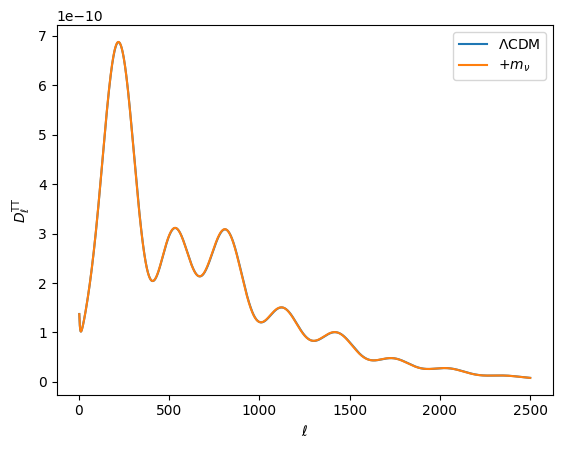

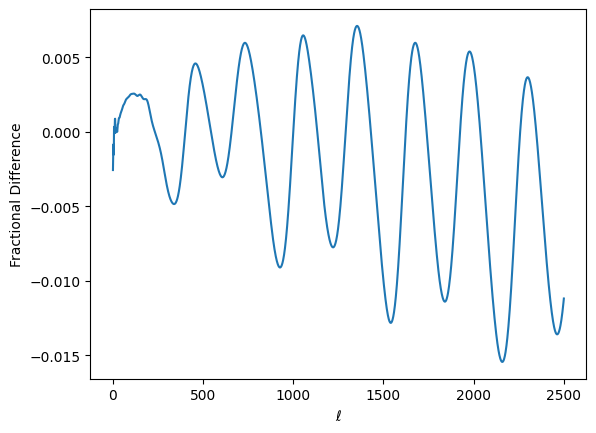

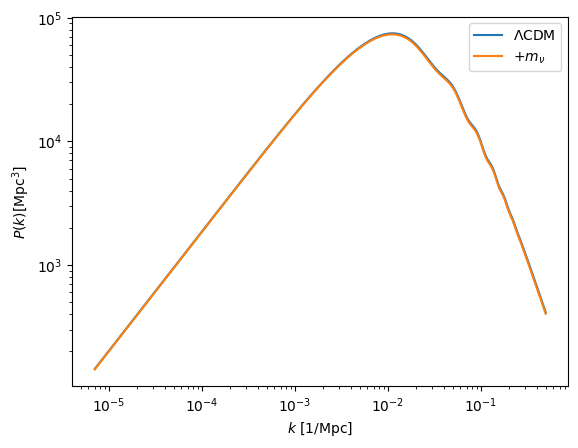

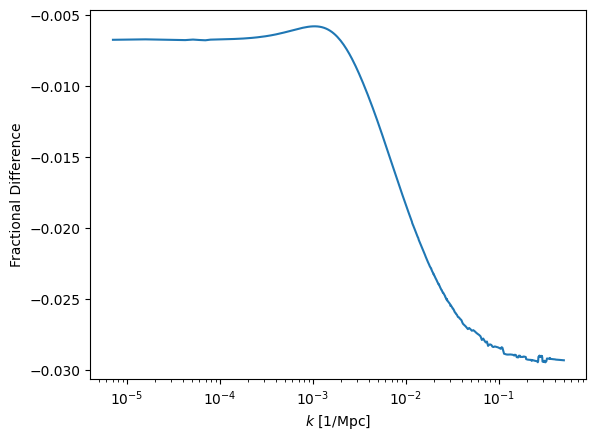

In [66]:
plt.plot(l, tt, label=r"$\Lambda {\rm CDM}$")
plt.plot(l, tt_mnu, label=r"$+m_\nu$")
plt.legend()
plt.ylabel(r"$D_\ell^{\rm TT}$")
plt.xlabel(r"$\ell$")
plt.show()

plt.plot(l, tt_mnu/tt - 1.)
plt.ylabel("Fractional Difference")
plt.xlabel(r"$\ell$")
plt.show()

plt.loglog(k, Pk, label=r"$\Lambda {\rm CDM}$")
plt.loglog(k, Pk_mnu, label=r"$+m_\nu$")
plt.legend()
plt.ylabel(r"$P(k) [{\rm Mpc}^3]$")
plt.xlabel(r"$k\ [1/{\rm Mpc}]$")
plt.show()

plt.plot(k, Pk_mnu/Pk - 1.)
plt.ylabel("Fractional Difference")
plt.xlabel(r"$k\ [1/{\rm Mpc}]$")
plt.xscale("log")
plt.show()

# Example: $w_0w_a {\rm CDM}$ (Dynamical Dark Energy)

Next we look at the first of our BSM scenarios, and demonstrate how one implements it in ABCMB. The dynamical dark energy has received much attention in light of the recent DESI data. In this model the constant dark energy equation of state $w=-1$ is modified with the time dependence $w(a) = w_0 + (1-a)w_a$. It's energy density is therefore no longer constant, but redshifts according to $\rho \propto a^{-3(1+w(a))}$.

In this minimal example, the now dynamical dark energy only modifieds the background energy density without introducing any perturbations. Though such scenarios have been discussed in the literature with the DE possibly interacting with dark matter, let's look at the background only case for now to see how one does it. 

In particular, we can save ourselves a little time by inheriting the DDE Class based on `BackgroundFluid`, and not `Fluid` directly. `BackgroundFluid` is a simple intermediate Class that itself inherits from `Fluid`, but with all perturbations related functions set trivially. Doing so saves us from the hassel of having to set them to something trivial by hand, and we only need the background functions as follows.

In [35]:
class DynamicalDarkEnergy(species.BackgroundFluid):

    num_ell_modes = 0 # This fluid has no perturbations
    name = "DynamicalDarkEnergy" # Give it a name
    
    def __init__(self, delta_idx, specs):
        super().__init__(delta_idx, specs) # Standard super init procedure, needed for all fluids

    def rho(self, lna, params):
        """
        Energy density at log scale factor lna.
        Should be in units of eV/cm^3.

        Parameterized as the redshift behavior based on its energy density today.
        rho = rho0 x a^{-3(1+w)}
        """
        # Energy density today
        rho0 = params["omega_Lambda"] * (3.*cnst.H0_over_h**2/8./jnp.pi/cnst.G)
        a = jnp.exp(lna)
        w = params["w0DE"] + (1-a)*params["waDE"] # We will be sure to pass these params
        
        return rho0 * a**(-3.*(1.+w))

    def P(self, lna, params):
        """
        Pressure at log scale factor lna.
        """
        a = jnp.exp(lna)
        w = params["w0DE"] + (1-a)*params["waDE"]
        return w*self.rho(lna, params)

We need to be careful not to double count the dark energy. By default, ABCMB will add the $\Lambda$ dark energy, whereas we are looking to replace it here. Therefore we must tell ABCMB not to use any default species and specify all fluids ourselves:

In [36]:
# Since we're not using default species, we need to add all the other fluids too.
user_species = {
    species.Baryon,
    species.Photon,
    species.ColdDarkMatter,
    species.MasslessNeutrino,
    DynamicalDarkEnergy
}

specs = {
    "use_LCDM_species" : False # Ask ABCDM not to use default species
}

w0wa = Model(specs, user_species=user_species)
print("w0wa:")
print(w0wa.species_dict)

w0wa:
{'DynamicalDarkEnergy': 0, 'MasslessNeutrino': 1, 'Baryon': 2, 'ColdDarkMatter': 3, 'Photon': 4}


As we can see we still have the five fluids in this model, only dark energy has been replaced by our `DynamicalDarkEnergy`. We are ready to run as long as we remember to pass in our BSM parameters, `w0DE` and `waDE`. Let's see how it compares to $\Lambda {\rm CDM}$.

In [37]:
params = {
    "w0DE" : -0.8,
    "waDE" : -0.6,
}

output_w0wa, aux_w0wa = w0wa.run_cosmology(params)

You did not specify either N_nu_massless or Neff, and did not ask LINX to compute these quantities.
N_nu_massless will be set to 3-N_nu_massive=3.

              /\  
             /  \   
            / /\ \  
           / /__\ \    ___   ___  
          / ______ \  | _ \ / __\ _  _  
         / /      \ \ |  _// /   | \/ | __  
        / /        \ \| _ \\ \___||\/||| -)  
       /_/          \_|___/ \___/||  |||_-) is compiling...
\_____/      



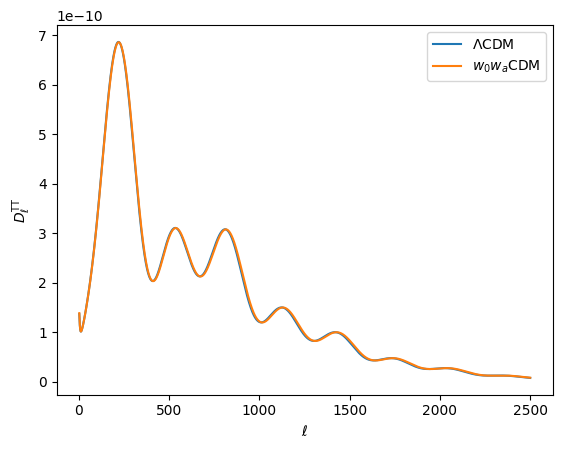

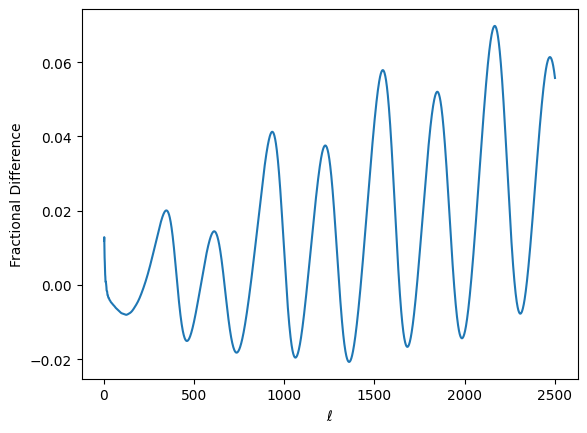

In [39]:
# Compare
tt_w0wa = output_w0wa[0] * l * (l+1) / 2 / jnp.pi

plt.plot(l, tt, label=r"$\Lambda {\rm CDM}$")
plt.plot(l, tt_w0wa, label=r"$w_0 w_a {\rm CDM}$")
plt.legend()
plt.ylabel(r"$D_\ell^{\rm TT}$")
plt.xlabel(r"$\ell$")
plt.show()

plt.plot(l, tt_w0wa/tt - 1.)
plt.ylabel("Fractional Difference")
plt.xlabel(r"$\ell$")
plt.show()

# Example: SIDR

The next example includes both background modifications and extra perturbations. We consider a strongly self interacting dark radiation scenario. The dark sector consists of an isolated, massless (or very light) particle whose self interaction is always stronger than Hubble. Such a radiation is considered to be "fluid" in nature and not "free-streaming", as are the descriptors in CLASS. In particular, the only relevant perturbations are the density and velocity perturbations, and no higher moments are needed. These two modes obey the time evolution equations

$
\begin{align}
\delta_{\rm dr}' &= -\frac{4 \theta_{\rm dr}}{3 \mathcal{H}} - \frac{2}{3}h' \\
\theta_{\rm dr}' &= \frac{k^2 \delta_{\rm dr}}{4 \mathcal{H}}\, ,
\end{align}
$

where $'$ denotes derivative w.r.t. $\ln{a}$, which is required in ABCMB.

We have created a `StandardFluid` Class inheriting from `Fluid`, where the three metric perturbation functions $\rho \delta$, $(\rho+P)\theta$ and $(\rho+P)\sigma$ are already set. This is applicable to the SIDR since the two perturbation modes are indeed $\delta$ and $\theta$. We therefore only need to implement two background functions $\rho$ and $P$, as well as two perturbation functions `y_ini` and `y_prime`: 

In [5]:
class SIDR(StandardFluid):
    
    # Number of modes in the Boltzmann Hierarchy
    num_ell_modes = 2 # Non free-streaming species only require density and velocity perturbations

    name = "SIDR"

    def __init__(self, delta_idx, specs):
        super().__init__(delta_idx, specs)
    
    def rho(self, lna, params):
        """
        Energy density at log scale factor lna.
        Should be in units of eV/cm^3.

        Here the energy density is parameterized in terms of the number of extra SM neutrino species:
        
        rho1nu = 7/8 x (4/11)^(4/3) x rhoCMB

        where rhoCMB = pi^2/15 TCMB0^4 / a^4,

        and rho_idr = N_idr x rho1nu
        """
        a = jnp.exp(lna)

        # Note: params['TCMB0'] is in eV, so we need three factors of 1/(hbar c) to convert to eV/cm^3
        rho1nu = 7./8. * (4./11.)**(4./3.) * jnp.pi**2 / 15. * params['TCMB0']**4 / a**4 / (cnst.hbar*cnst.c)**3
        return params["N_idr"] * rho1nu

    def P(self, lna, params):
        """
        Pressure at log scale factor lna.
        For fully relativistic species this is simply rho/3.
        """
        return self.rho(lna, params)/3.

    def y_ini(self, k, tau_ini, om, args):
        """
        Adiabatic superhorizon initial conditions for SIDR.
        For all relativistic species they are matched to neutrinos.
        """
        params = args
        R_nu = params['R_nu']

        delta = - (k*tau_ini)**2/3. * (1.-om*tau_ini/5.)
        theta = - k*(k*tau_ini)**3/36./(4.*R_nu+15.) \
                * (4.*R_nu+11.+12.-3.*(8.*R_nu**2+50.*R_nu+275.)/20./(2.*R_nu+15.)*tau_ini*om)
        return jnp.array([delta, theta])

    def y_prime(self, k, lna, metric_h_prime, metric_eta_prime, y, args):
        """
        Derivatives of the SIDR perturbations w.r.t. lna.
        """
        BG, params, _, _ = args
        aH = BG.aH(lna, params)

        # First find the delta and theta that belong to SIDR
        delta = y[self.delta_idx]
        theta = y[self.delta_idx+1]
        
        delta_prime = -4./3./aH*theta - 2./3.*metric_h_prime
        theta_prime = k**2/aH*delta/4.

        return jnp.array([delta_prime, theta_prime])

Here `y_ini` returns the two values for the initial $\delta$ and $\theta$. The expressions are matched to CLASS sychronous gauge, and in particular uses the `om` parameter defined as $\omega \equiv \frac{a \rho_m}{\sqrt{\rho_r}}\sqrt{\frac{8 \pi G}{3}}$, as well as $R_\nu \equiv \rho_\nu / \rho_r$.

The arguments of `y_prime` include the wavenumber, time, the two metric perturbations, the full perturbation equations vector `y`, as well as a tuple `args = (BG, params, species_list, species_dict)`. `BG` and `params` provide the background quantities and cosmological parameters respectively, while the `species_list` and `species_dict` provide pointers to other fluids that are not needed for now. These will become relevant when we next look at a coupled species.

In [7]:
# Here since SIDR is an extra fluid and is not meant to replace any LCDM fluids, we can leave the default species on.
user_species = (
    SIDR,
)

specs = {
    "max_steps_PE" : 4096,
}

SIDRmodel = Model(specs, user_species)
print("SIDR model:")
print(SIDRmodel.species_dict)

SIDR model:
{'DarkEnergy': 0, 'ColdDarkMatter': 1, 'Baryon': 2, 'Photon': 3, 'MasslessNeutrino': 4, 'SIDR': 5}


Here we used an extra `specs` parameters `max_steps_PE`. This parameter tells the diffrax adaptive step size solver what is the maximum number of steps it should expect to take, in order to solve the linear perturbations equations. This number is 2048 by default, but adding new physics scenarios such as the SIDR can mke these equations more difficult. With this method we allow diffrax to take more steps to solve, but this may increase runtime somewhat. 

In [8]:
params = {
    'N_idr' : jnp.array(.3), # Only extra parameter, number of equivalent SM neutrinos.
}

In [9]:
output_SIDR, aux_SIDR = SIDRmodel.run_cosmology(params)

You did not specify either N_nu_massless or Neff, and did not ask LINX to compute these quantities.
N_nu_massless will be set to 3-N_nu_massive=3.

              /\  
             /  \   
            / /\ \  
           / /__\ \    ___   ___  
          / ______ \  | _ \ / __\ _  _  
         / /      \ \ |  _// /   | \/ | __  
        / /        \ \| _ \\ \___||\/||| -)  
       /_/          \_|___/ \___/||  |||_-) is compiling...
\_____/      



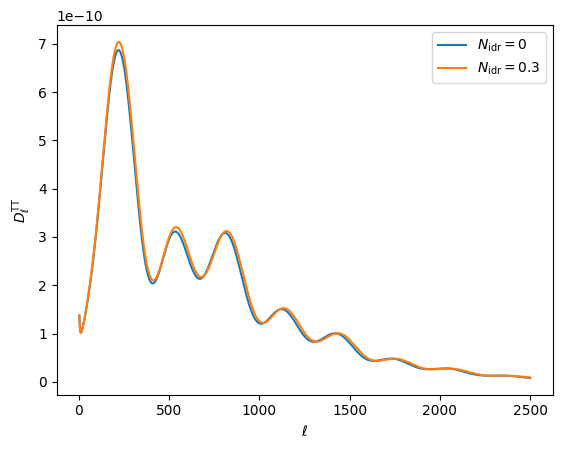

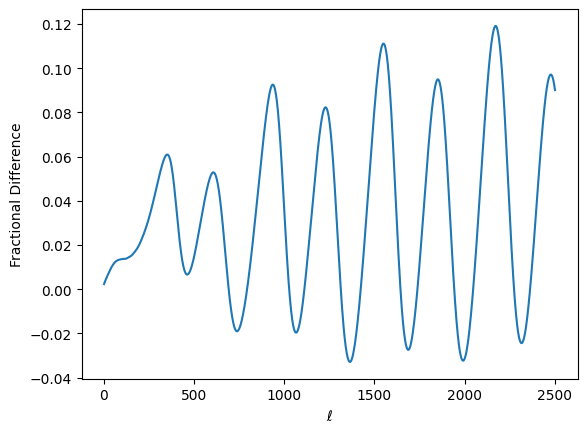

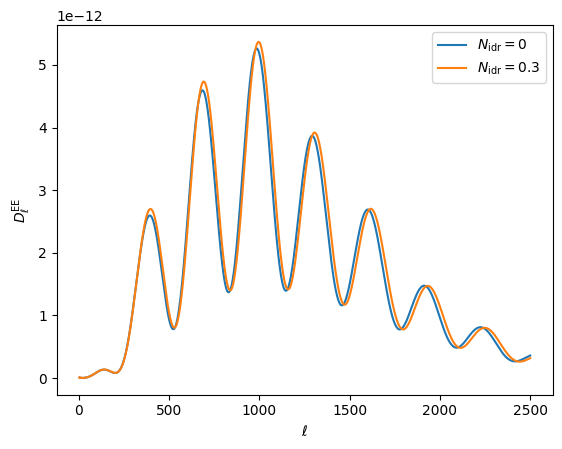

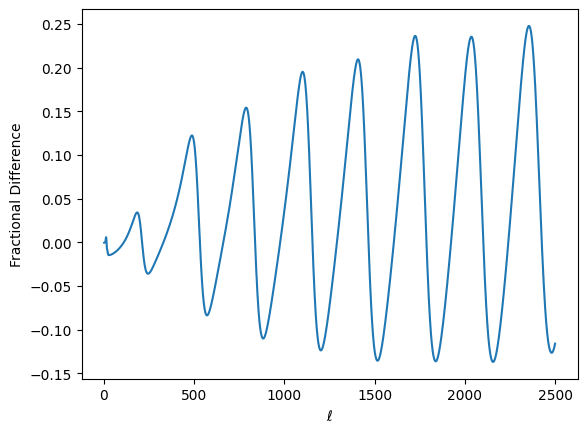

In [33]:
tt_SIDR = output_SIDR[0] * l * (l+1) / 2 / jnp.pi
ee_SIDR = output_SIDR[2] * l * (l+1) / 2 / jnp.pi

plt.plot(l, tt, label=r"$N_{\rm idr}=0$")
plt.plot(l, tt_SIDR, label=r"$N_{\rm idr}=0.3$")
plt.legend()
plt.ylabel(r"$D_\ell^{\rm TT}$")
plt.xlabel(r"$\ell$")
plt.show()

plt.plot(l, tt_SIDR/tt - 1.)
plt.ylabel("Fractional Difference")
plt.xlabel(r"$\ell$")
plt.show()

plt.plot(l, ee, label=r"$N_{\rm idr}=0$")
plt.plot(l, ee_SIDR, label=r"$N_{\rm idr}=0.3$")
plt.legend()
plt.ylabel(r"$D_\ell^{\rm EE}$")
plt.xlabel(r"$\ell$")
plt.show()

plt.plot(l, ee_SIDR/ee - 1.)
plt.ylabel("Fractional Difference")
plt.xlabel(r"$\ell$")
plt.show()

# Example: Non-Abelian Dark Matter

In the last example we will see how fluids can interact in ABCMB. This is also acomplished easily with the `Fluid` module.

We consider the dark sector scenario where all of the dark matter mildly scatter with the dark radiation. This can be realised in the Non-Abelian Dark Matter (NADM) model (see https://arxiv.org/pdf/1708.09406), implementated in CLASS under the NADM parameterization. We continue to study the case where the dark radiation itself strongly interacts to maintain a fluid nature, where now the velocity perturbations of the dark matter and dark radiation are modified as

$
\begin{align}
\theta_{\rm dm}' &= -\theta_{\rm dm} + \frac{\Gamma_{0, {\rm nadm}}}{a \mathcal{H}} (\theta_{\rm dr}-\theta_{\rm dm})\\
\theta_{\rm dr}' &= \frac{k^2 \delta_{\rm dr}}{4 \mathcal{H}} + R\frac{\Gamma_{0, {\rm nadm}}}{a \mathcal{H}} (\theta_{\rm dm}-\theta_{\rm dr})\\
R &\equiv \frac{3 \rho_{\rm dm}}{4 \rho_{\rm dr}}\, ,
\end{align}
$

where $R$ enforces energy-momentum conservation, and $\Gamma_{0, {\rm nadm}}$ is the dark matter-dark radiation collision rate today, in units of $1/{\rm Mpc}$.


Once again, we can use object inheritance to save ourselves a good bit of trouble. This is by recognizing that the IDM class is not entirely different from CDM; they differ only at the perturbations level while having the same background energy density. So we can define a new class

In [44]:
class IDM(species.ColdDarkMatter):

    num_ell_modes = 2 # Interacting DM will have velocity perturbation.
    name = "InteractingDarkMatter"

    def __init__(self, delta_idx, specs):
        super().__init__(delta_idx, specs)

    def y_ini(self, k, tau_ini, om, args):
        """
        Adiabatic initial conditions.
        For non-relativistic species we match to CDM and baryons for density, and baryons for velocity
        """
        params = args
        delta = -(k*tau_ini)**2/4. * (1.-om*tau_ini/5.)
        theta = - k**4 * tau_ini**3/36. * (1.-3.*(1.+5.*params['R_b']-params['R_nu'])/20./(1.-params['R_nu'])*om*tau_ini)
        return jnp.array([delta, theta])

    def y_prime(self, k, lna, metric_h_prime, metric_eta_prime, y, args):
        BG, params, species_list, species_dict = args
        
        # Get IDR from list
        i = species_dict["InteractingDarkRadiation"] 
        IDR = species_list[i]

        a = jnp.exp(lna)
        aH = BG.aH(lna, params)

        delta = y[self.delta_idx]
        theta = y[self.delta_idx+1]
        theta_idr = y[IDR.delta_idx+1]
        
        delta_prime = -theta/aH-metric_h_prime/2.
        theta_prime = -theta + params["Gamma_0_nadm"]/a/aH * (theta_idr - theta)
        
        return jnp.array([delta_prime, theta_prime])

where we have given the class a new name as well as updated its `num_ell_modes=2`, now having a velocity perturbation as well. We have only implemented a new initial conditions function and a new derivative functions. If we call `IDM.rho()` or `IDM.rho_delta()`, its parent class of `ColdDarkMatter` will execute those functions. If we call `IDM.y_ini()` or `IDM.y_prime()`, our new implementations will go through because these are the functions that have overridden those of the parent class. 

Here's a challenge: the `IDM.y_prime` function needs quantities that belong to the `IDR` class, but the `IDM` class only has access to its own functions and fields. How does it collect quantities such as $\theta_{\rm dr}$ and $\rho_{\rm dr}$?

We solve this problem by passing in two book-keeping objects in the `args`: `species_list` and `species_dict`, which come in along side the background and parameter objects. The former, `species_list` is a tuple containing all fluids present the computation. `species_dict` is a dictionary (key : str, value : int) that stores the index position of any particular fluid in that tuple, using that fluid's `name` as the key. Thus, having `species_list` and `species_dict` allows us to easily pick out any particular fluid, which is done in the `IDM.y_prime()` function on the second and third lines; first we extract the position of IDR using `species_dict`, then we retrieve the fluid class itself in `species_list`. The `args` parameter is automatically passed in when your fluid is called by ABCMB, so you do not have to worry about what `args` is, but only how your fluid will use it.

Once we have the `IDR` class at hand, we can simply extract $\theta_{\rm dr}$ by calling `theta_idr = y[IDR.delta_idx+1]`, using the `IDR` class' field that we now have access to.

For the dark radiation things are even simpler. We can inherit from the SIDR class we wrote in the previous section, where now only one line in the derivative needs modification!

In [45]:
class IDR(SIDR):

    name = "InteractingDarkRadiation"

    def __init__(self, delta_idx, specs):
        super().__init__(delta_idx, specs)

    def y_prime(self, k, lna, metric_h_prime, metric_eta_prime, y, args):
        """
        Derivatives of the SIDR perturbations w.r.t. lna.
        """
        BG, params, species_list, species_dict = args
        
        # Get IDM from list
        i = species_dict["InteractingDarkMatter"]
        IDM = species_list[i]

        a = jnp.exp(lna)
        aH = BG.aH(lna, params)
        R = 3. * IDM.rho(lna, params) / 4. / self.rho(lna, params)

        # First find the delta and theta that belong to SIDR
        delta = y[self.delta_idx]
        theta = y[self.delta_idx+1]
        theta_idm = y[IDM.delta_idx+1]
        
        delta_prime = -4./3./aH*theta - 2./3.*metric_h_prime
        theta_prime = k**2/aH*delta/4. + R * params["Gamma_0_nadm"]/a/aH * (theta_idm - theta)

        return jnp.array([delta_prime, theta_prime])

As in the dynamical dark energy case, we have a new fluid that is replacing an existing $\Lambda {\rm CDM}$ fluid. We must set the default species flag to false and manually add all necessary fluids.

In [49]:
lmax = 2500
specs = {
    "use_LCDM_species" : False,
    "max_steps_PE" : 4096,
}
user_species = (
    species.DarkEnergy, 
    IDM, 
    IDR, 
    species.Baryon,
    species.Photon, 
    species.MasslessNeutrino
)

NADMmodel = Model(specs, user_species)

Let's check that our model picked up the correct fluids:

In [50]:
NADMmodel.species_dict

{'DarkEnergy': 0,
 'InteractingDarkMatter': 1,
 'InteractingDarkRadiation': 2,
 'Baryon': 3,
 'Photon': 4,
 'MasslessNeutrino': 5}

In [51]:
params = {
    'N_idr' : jnp.array(0.3),
    'Gamma_0_nadm' : jnp.array(4.e-7),
}

In [52]:
output_NADM, aux_NADM = NADMmodel.run_cosmology(params)
Pk_NADM = output_NADM[3]
tt_NADM = output_NADM[0] * l * (l+1) / 2 / jnp.pi

You did not specify either N_nu_massless or Neff, and did not ask LINX to compute these quantities.
N_nu_massless will be set to 3-N_nu_massive=3.

              /\  
             /  \   
            / /\ \  
           / /__\ \    ___   ___  
          / ______ \  | _ \ / __\ _  _  
         / /      \ \ |  _// /   | \/ | __  
        / /        \ \| _ \\ \___||\/||| -)  
       /_/          \_|___/ \___/||  |||_-) is compiling...
\_____/      



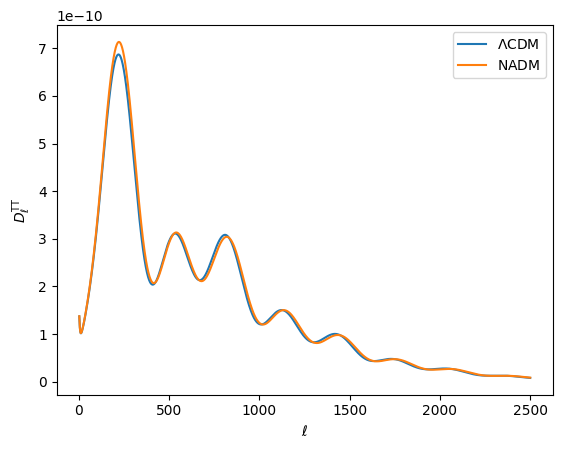

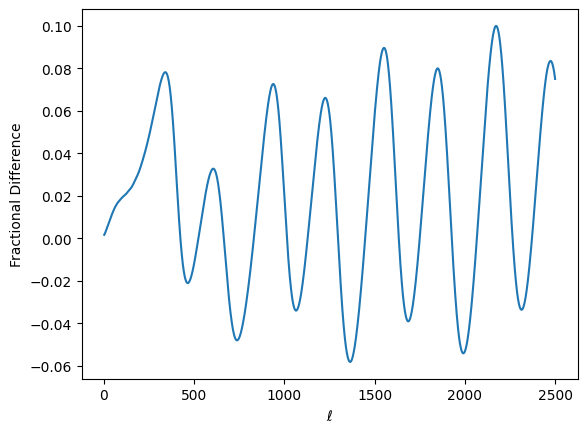

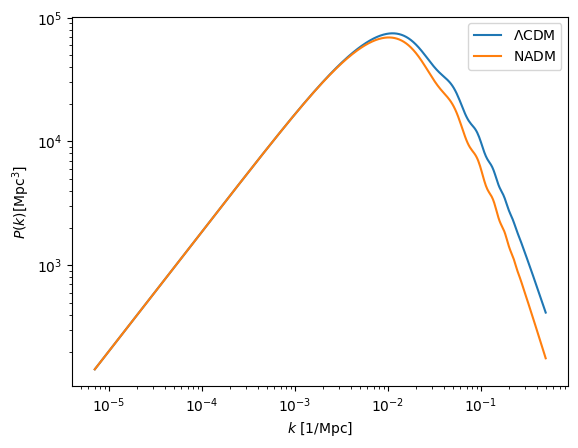

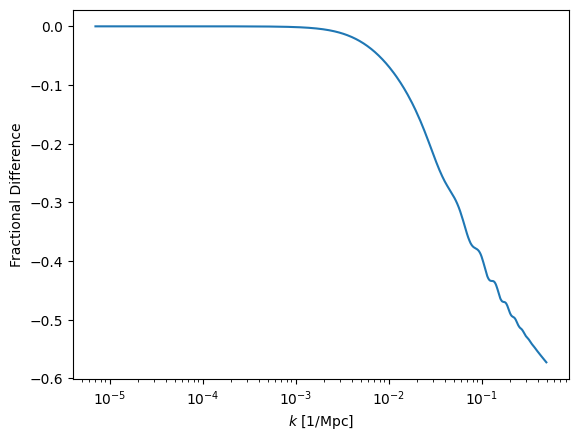

In [61]:
plt.plot(l, tt, label=r"$\Lambda {\rm CDM}$")
plt.plot(l, tt_NADM, label=r"${\rm NADM}$")
plt.legend()
plt.ylabel(r"$D_\ell^{\rm TT}$")
plt.xlabel(r"$\ell$")
plt.show()

plt.plot(l, tt_NADM/tt - 1.)
plt.ylabel("Fractional Difference")
plt.xlabel(r"$\ell$")
plt.show()

plt.loglog(k, Pk, label=r"$\Lambda {\rm CDM}$")
plt.loglog(k, Pk_NADM, label=r"${\rm NADM}$")
plt.legend()
plt.ylabel(r"$P(k) [{\rm Mpc}^3]$")
plt.xlabel(r"$k\ [1/{\rm Mpc}]$")
plt.show()

plt.plot(k, Pk_NADM/Pk - 1.)
plt.ylabel("Fractional Difference")
plt.xlabel(r"$k\ [1/{\rm Mpc}]$")
plt.xscale("log")
plt.show()

We observe again peak shifts in the $TT$ power spectrum, mainly due to the extra dark radiation. On the matter power spectrum side, additional dark matter scattering hinders gravitational clustering, enough to suppress the power at small scales. 

# Cheat Sheet: Define your own species!

We invite you to build your new physics species here! Here's an outline for your starting choices:

First does your new physics involve cosmological perturbations? 
- If no, inherit from `BackgroundFluid`.
- If yes, are your perturbation equations ordered in $\delta, \theta, \sigma \dots$?
    - If yes, inherit from `StandardFluid` and let ABCMB take care of metric perturbations for you.
    - If no, inherit directly from `Fluid`, and you must implement your own metric perturbation contributions (`rho_plus_P_theta` etc.).
 
Second, set the required fields:
- If your fluid has perturbations, set `num_ell_modes` to the appropriate number of equations.
- If your fluid is non-relativistic today and should contribute towards the matter power spectrum, set `is_matter=True`.
- Name your fluid!

Regardless of your choices above, you should now implement the `__init__` function. Copy it over from any of the existing fluids, it's only really important that you include the `super().__init__(delta_idx, specs)` line.

Implement your background functions `rho` and `P`, required for all fluids. If your fluid is at the background level only and does not need and pressure, simply implement something trivial.

For the perturbed fluids, implement your derivative functions. Make sure both `y_ini` and `y_prime` follow the input, output syntax, in particular the outputs should be `jnp.array` of size `num_ell_modes`.

If you have any unique functions or fields, feel free to add them anywhere in this process. For example, it is u